# ENCODE cCRE regions & LFC enrichment  

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pyranges as pr
import re
import scipy.stats as stats
from Bio import SeqIO
import math
import matplotlib as mpl
from matplotlib import font_manager
from scipy.stats import ks_2samp
import itertools

arial_path = "/media/scratch/fy2306/tools/fonts"
font_files = font_manager.findSystemFonts(fontpaths=arial_path)

for file in font_files:
    font_manager.fontManager.addfont(file)
    
mpl.rcParams['font.family'] = 'Arial'
import warnings
warnings.filterwarnings("ignore")


In [5]:
id_prefix_list = [
	"MYC_GFP_"
]

In [6]:
# remove negative controls that can be mapped to the genome (with bowtie)
mapped_ctrl_path = "/media/scratch/fy2306/projects/base_editing/data/bowtie/all/all_sgrna_seqs.bowtie_hg38.mismatch1.processed.tsv"
mapped_ctrl_df = pd.read_csv(mapped_ctrl_path, sep="\t")
mapped_ctrl_df = mapped_ctrl_df[
    mapped_ctrl_df['id'].str.startswith(('Random', 'Non-targeting-controls', 'AAVS1'))
    & ~(mapped_ctrl_df['id'].str.startswith('AAVS1') & (mapped_ctrl_df['Alignments_NM0'] == 1) & (mapped_ctrl_df['Alignments_NM1'] == 0))
]
mapped_ctrl_list = mapped_ctrl_df["id"].tolist()
print(len(mapped_ctrl_list))
all_ctrl = [
    record.id for record in SeqIO.parse("/media/scratch/fy2306/projects/base_editing/data/bowtie/negative_controls/input/negative_controls.fa", "fasta")
    ]
clean_ctrl_list = list(set(all_ctrl)-set(mapped_ctrl_list))
print(len(clean_ctrl_list))
print(len(all_ctrl))

91
474
565


In [7]:
# randomly group nc sgrnas
def group_and_aggregate(df, group_size, random_state=None):
    df_shuffled = df.sample(frac=1, random_state=random_state).reset_index(drop=True)
    
    num_groups = len(df_shuffled) // group_size
    df_trimmed = df_shuffled.iloc[:num_groups * group_size]
    
    grouped = np.array_split(df_trimmed, num_groups)
    
    aggregated = []
    for group in grouped:
        sgrna_concat = ','.join(group['sgrna'].astype(str))
        avg_lfc = group['per time unit LFC'].mean()
        aggregated.append({
            'sgrna': sgrna_concat,
            'per time unit LFC': avg_lfc
        })
    
    return pd.DataFrame(aggregated)

In [8]:
def encode_lfc(
	gene, myc_var, cons_col,
	date,
	test_name,
	nc_test_name,
	merge_method_nucleotide, 
	win_size,
	baseline,
	treatments,
	day_numbers,
	cons_subset,
	merge_method_replicate,
	per_time_unit=True, abs_LFC=False):

	# preprocess
	df_path = f"/media/scratch/fy2306/projects/base_editing/data/{date}/mageck/{test_name}/{merge_method_nucleotide}/myc_repeats/{win_size}/MYC_U1.gene_summary.txt"
	df = pd.read_csv(df_path, sep="\t")
	pattern = f"^({'|'.join(map(re.escape, id_prefix_list))})([0-9]*\.?[0-9]+)"
	df = df[df['id'].str.match(pattern)]
	edited_pos_chr_col = "indel_base_pos_chr"	# nucleotide pos
	df[edited_pos_chr_col] = df['id'].str.extract(pattern)[1].astype(int)	# 1-based

	# merge
	treatment_lfc_columns = [f"{treatment}_vs_{baseline}|neg|lfc" for treatment in treatments]
	treatment_fdr_columns = [f"{treatment}_vs_{baseline}|neg|fdr" for treatment in treatments]
	treatment_fdr_goodsgrna_columns = [f"{treatment}_vs_{baseline}|neg|goodsgrna" for treatment in treatments]
	treatment_fdr_pos_columns = [f"{treatment}_vs_{baseline}|pos|fdr" for treatment in treatments]
	treatment_fdr_pos_goodsgrna_columns = [f"{treatment}_vs_{baseline}|pos|goodsgrna" for treatment in treatments]
	if per_time_unit:
		for col, day in zip(treatment_lfc_columns, day_numbers):
			df[col] = df[col] / (day + 0) # per time unit.

	if merge_method_replicate == "mean":
		df["neg|lfc"] = df[treatment_lfc_columns].mean(axis=1)
	# copied from lfc_to_seq
	for fdr_col, goodsgrna_col in zip(treatment_fdr_columns, treatment_fdr_goodsgrna_columns):
		df.loc[df[goodsgrna_col] < 2, fdr_col] = 1
	df["neg|fdr"] = df[treatment_fdr_columns].apply(lambda row: sorted(row)[1], axis=1)	# second-lowest fdr
	df["direction"] = df[treatment_lfc_columns].apply(lambda row: (row.gt(0).all() or row.lt(0).all()), axis=1)
	for fdr_col, goodsgrna_col in zip(treatment_fdr_pos_columns, treatment_fdr_pos_goodsgrna_columns):
		df.loc[df[goodsgrna_col] < 2, fdr_col] = 1
	df["pos|fdr"] = df[treatment_fdr_pos_columns].apply(lambda row: sorted(row)[1], axis=1)	# second-lowest fdr
	df["fdr"] = df[["neg|fdr", "pos|fdr"]].min(axis=1)
	if abs_LFC:
		df["neg|lfc"] = df["neg|lfc"].abs()

	# add repeats
	rmsk_path = "/media/dna/fy2306/genomes/hg38/RepeatMasker/rmsk.txt"
	rmsk_colnames = ["bin", "swScore", "milliDiv", "milliDel", "milliIns", "genoName", "genoStart", "genoEnd", "genoLeft", "strand", "repName", "repClass", "repFamily", "repStart", "repEnd", "repLeft", "id"]
	rmsk = pd.read_csv(rmsk_path, sep="\t", header=None, names=rmsk_colnames)
	rmsk = rmsk[rmsk['genoName'] == "chr8"]
	# rmsk: 0-based
	rmsk_ranges = pr.PyRanges(rmsk.rename(columns={
	'genoName': 'Chromosome',
	'genoStart': 'Start',
	'genoEnd': 'End'
	}))

	# base_pos: 1-based
	df['Start'] = df[edited_pos_chr_col] - 1
	df['End'] = df['Start'] + 1
	df['Chromosome'] = 'chr8'

	df["orig_index"] = df.index
	df_ranges = pr.PyRanges(df[['Chromosome', 'Start', 'End', 'orig_index']])

	overlap = df_ranges.intersect(rmsk_ranges, how="containment")	# in pyranges: “containment” reports intervals where the overlapping is contained within it, gives you the intervals in self be completely within the intervals in other
	overlap_indices = overlap.df['orig_index'].unique()

	df["indel_repeats"] = False
	df.loc[overlap_indices, "indel_repeats"] = True

	# process the negative controls
	df_nc = None
	for treatment in treatments:
		df_nc_path = f"/media/scratch/fy2306/projects/base_editing/data/{date}/mageck/{nc_test_name}/MYC_U1.{treatment}_vs_{baseline}.sgrna_summary.txt"
		df_nc_rep = pd.read_csv(df_nc_path, sep="\t", usecols=["sgrna", "Gene", "LFC"])
		df_nc_rep = df_nc_rep[df_nc_rep["Gene"].isin(["AAVS1", "NT", "Random"])]
		df_nc_rep = df_nc_rep.drop('Gene', axis=1)
		df_nc_rep = df_nc_rep.rename(columns={"LFC": f"LFC_{treatment}"})
		if df_nc is None:
			df_nc = df_nc_rep
		else:
			# Merge on 'sgrna'
			df_nc = pd.merge(df_nc, df_nc_rep, on="sgrna", how="inner")
	print(len(df_nc))

	treatment_lfc_nc_columns = [f"LFC_{treatment}" for treatment in treatments]

	if per_time_unit:
		for col, day in zip(treatment_lfc_nc_columns, day_numbers):
			df_nc[col] = df_nc[col] / (day + 0) # per time unit.

	if merge_method_replicate == "mean":
		df_nc["per time unit LFC"] = df_nc[treatment_lfc_nc_columns].mean(axis=1)

	# remove mismatches
	df_nc = df_nc[~(df_nc["sgrna"].isin(mapped_ctrl_list))]
	df_nc = df_nc[['sgrna', 'per time unit LFC']]

	# random group of df_nc
	n_repeats = 1000
	all_results = []

	for seed in range(n_repeats):
		df_nc_result = group_and_aggregate(df_nc, group_size=2*int(win_size), random_state=seed)
		all_results.append(df_nc_result)

	df_nc_combined = pd.concat(all_results, ignore_index=True)
	nc_combined_median_value = df_nc_combined["per time unit LFC"].median()
	print(nc_combined_median_value)

	df["neg|lfc"] = df["neg|lfc"] - nc_combined_median_value

	df = df[["id", edited_pos_chr_col, "neg|lfc", "indel_repeats", "fdr", "direction"]]
	print(df[df[edited_pos_chr_col] == 127741050])

	# load in lib
	lib_path = f"/media/scratch/fy2306/projects/base_editing/data/grna_type/MYC-lib-for-mageck.type.{myc_var}.organized.txt"
	df_lib = pd.read_csv(lib_path, sep="\t", usecols=[edited_pos_chr_col, cons_col])
	# duplicates = df_lib.groupby(edited_pos_chr_col)[cons_col].nunique()
	# conflicts = duplicates[duplicates > 1]
	# if not conflicts.empty:
	# 	print("Found rows with same edited_pos_chr_col but different cons_col:")
	# 	print(conflicts)
	# else:
	# 	print("No conflicts found.")
	df_lib = df_lib.drop_duplicates(subset=edited_pos_chr_col)
	df = pd.merge(df, df_lib, on=edited_pos_chr_col, how='left')
	df = df[df["indel_repeats"] == False]
	df[edited_pos_chr_col] = df[edited_pos_chr_col].astype(int)
	# df: "id", edited_pos_chr_col, "neg|lfc", "indel_repeats", cons_col

	# load in ENCODE  
	encode_path = "/media/scratch/fy2306/projects/base_editing/data/public_data/ENCODE_cCRE_MYC.tsv"
	bed = pd.read_csv(encode_path, sep="\t")
	bed = bed.sort_values(["chrom", "chromStart"], kind="mergesort")
	starts = bed["chromStart"].to_numpy(np.int64)
	ends   = bed["chromEnd"].to_numpy(np.int64)
	labels = bed["ucscLabel"].astype(str).to_numpy(object)

	df["cCRE"] = "non-cCRE"

	pos_0 = df[edited_pos_chr_col].astype(np.int64).to_numpy() - 1
	j = np.searchsorted(starts, pos_0, side="right") - 1
	valid = (j >= 0) & (pos_0 < ends[np.clip(j, 0, len(ends)-1)])
	df.loc[valid, "cCRE"] = labels[j[valid]]

	# print stats
	df_sig = df[(df['fdr'] < 0.05) & (df['direction'] == True)]
	print(f"Pct of sig bps in 5' half ({len(df_sig[(df_sig[cons_col] != 'coding') & (df_sig[edited_pos_chr_col] < 127738759)])}) overlapping with cCREs: {len(df_sig[(df_sig[cons_col] != 'coding') & (df_sig[edited_pos_chr_col] < 127738759) & (df_sig['cCRE'] != 'non-cCRE')]) / len(df_sig[(df_sig[cons_col] != 'coding') & (df_sig[edited_pos_chr_col] < 127738759)]) * 100:.2f}%")
	print(f"Pct of sig bps in 5' half overlapping with prom: {len(df_sig[(df_sig[cons_col] != 'coding') & (df_sig[edited_pos_chr_col] < 127738759) & (df_sig['cCRE'] == 'prom')]) / len(df_sig[(df_sig[cons_col] != 'coding') & (df_sig[edited_pos_chr_col] < 127738759)]) * 100:.2f}%")
	print(f"Pct of sig bps in 5' half overlapping with enhP: {len(df_sig[(df_sig[cons_col] != 'coding') & (df_sig[edited_pos_chr_col] < 127738759) & (df_sig['cCRE'] == 'enhP')]) / len(df_sig[(df_sig[cons_col] != 'coding') & (df_sig[edited_pos_chr_col] < 127738759)]) * 100:.2f}%")
	print(df_sig[(df_sig[cons_col] != 'coding') & (df_sig[edited_pos_chr_col] < 127738759)]["cCRE"].value_counts())
	print(df_sig[(df_sig[cons_col] != 'coding') & (df_sig[edited_pos_chr_col] < 127738759) & (df_sig["cCRE"] == "enhD")][edited_pos_chr_col])

	if cons_subset != "all":
		df = df[df[cons_col].isin(cons_subset)]

	print(df.groupby("cCRE").size())

	# cdf
	plt.figure(figsize=(4,4))

	colors = {
		"non-cCRE": "#7F7F7F",
		"prom": "#FF0000",
		"enhP": "#E89700",
		"enhD": "#FFD015"
	}

	order = ["prom", "enhP", "enhD", "non-cCRE"]

	for name in order:
		group = df[df["cCRE"] == name]
		x = np.sort(group["neg|lfc"].to_numpy())
		y = np.arange(1, len(x) + 1) / len(x)
		plt.plot(x, y, label=f'{name} (N={len(x)})', color=colors[name])

	# group_low = df[df['cCRE'] == 'prom']['neg|lfc']
	# median_low = group_low.median()
	# group_high = df[df['cCRE'] == 'non-cCRE']['neg|lfc']
	# median_high = group_high.median()
	# ks_stat, p_value = ks_2samp(group_low, group_high)
	# shift = abs(median_high - median_low)
	# print("KS test between prom and non-cCRE:")
	# print(f"KS statistic: {ks_stat}, p-value: {p_value}, median shift: {shift}")
	group_col = "cCRE"
	value_col = "neg|lfc"

	groups = df[group_col].dropna().unique()

	rows = []
	for g1, g2 in itertools.combinations(groups, 2):
		x = df.loc[df[group_col] == g1, value_col].dropna()
		y = df.loc[df[group_col] == g2, value_col].dropna()

		# skip if too small
		if len(x) < 2 or len(y) < 2:
			continue

		ks_stat, p_value = ks_2samp(x, y)

		med1 = x.median()
		med2 = y.median()
		shift = abs(med2 - med1)

		rows.append({
			"group1": g1,
			"group2": g2,
			"n1": len(x),
			"n2": len(y),
			"median1": med1,
			"median2": med2,
			"median_shift": shift,
			"ks_stat": ks_stat,
			"p_value": p_value
		})

	pairwise_ks = pd.DataFrame(rows).sort_values("p_value")
	for _, r in pairwise_ks.iterrows():
		print(f"KS test between {r['group1']} and {r['group2']}:")
		print(f"  KS statistic: {r['ks_stat']:.4f}, p-value: {r['p_value']:.3e}, median shift: {r['median_shift']:.4f}")


	plt.xlabel("base pair phenotype score", fontsize=14)
	plt.xlim(-0.05, 0.025)
	plt.xticks([-0.05, -0.025, 0, 0.025], fontsize=13)
	plt.ylabel("CDF", fontsize=14)
	plt.yticks([0, 0.5, 1], fontsize=13)
	# plt.axhline(y = 0.5, color='grey', linestyle="--", alpha=0.5)
	plt.title("Flanking regions + introns", fontsize=14)
	plt.legend(loc="upper left", frameon=False, fontsize=11)
	plt.gca().spines['top'].set_visible(False)
	plt.gca().spines['right'].set_visible(False)
	plt.savefig("/media/scratch/fy2306/projects/base_editing/plots/screening/basepair_lfc_cCRE_cdf.pdf", 
				bbox_inches="tight",
				dpi=300,              
				transparent=True,
				format='pdf')
	plt.show()

565
-0.0028773212890625005
                     id  indel_base_pos_chr   neg|lfc  indel_repeats      fdr  \
1211  MYC_GFP_127741050           127741050 -0.039894          False  0.20216   

      direction  
1211       True  
Pct of sig bps in 5' half (195) overlapping with cCREs: 79.49%
Pct of sig bps in 5' half overlapping with prom: 23.59%
Pct of sig bps in 5' half overlapping with enhP: 54.36%
cCRE
enhP        106
prom         46
non-cCRE     40
enhD          3
Name: count, dtype: int64
292    127738227
293    127738228
555    127738226
Name: indel_base_pos_chr, dtype: int64
cCRE
enhD        2405
enhP        2206
non-cCRE    1939
prom         391
dtype: int64
KS test between enhD and prom:
  KS statistic: 0.2644, p-value: 3.277e-21, median shift: 0.0129
KS test between non-cCRE and prom:
  KS statistic: 0.2586, p-value: 1.180e-19, median shift: 0.0131
KS test between enhP and enhD:
  KS statistic: 0.1023, p-value: 6.087e-11, median shift: 0.0043
KS test between enhP and non-cCRE:
 

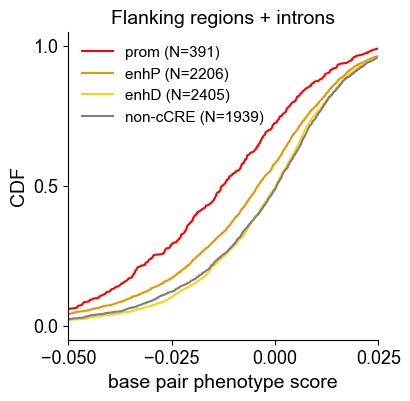

In [9]:
gene = "MYC"
myc_var = "myc2_indel"
cons_col = "indel_consequences_more"
date = "20250416"
test_name = "test-1-standard-nucleotide/test"
nc_test_name = "test-1-standard/test"
merge_method_nucleotide = "mean"
win_size = "4"
baseline = "Cas9-HMOI_D0"
treatments = ["Cas9-LMOI_D20", "Cas9-LMOI_D8", "Cas9_SpRY_L_MOI_D_20", "Cas9_SpRY_L_MOI_D_8"]
day_numbers = [20, 8, 20, 8]
# cons_subset = ["upstream_flanking", "5_prime_UTR", "short_5_prime_UTR", "intron_1", "intron_2", "short_3_prime_UTR", "3_prime_UTR", "downstream_flanking"]
cons_subset = ["upstream_flanking", "intron_1", "intron_2", "downstream_flanking"]
# cons_subset = ["upstream_flanking", "5_prime_UTR", "short_5_prime_UTR", "intron_1", "intron_2"]
merge_method_replicate = "mean"
encode_lfc(
	gene, myc_var, cons_col,
	date,
	test_name,
	nc_test_name,
	merge_method_nucleotide, 
	win_size,
	baseline,
	treatments,
	day_numbers,
	cons_subset,
	merge_method_replicate, 
	per_time_unit=True, abs_LFC=False)